# Ensemble spread under increasing streamflow — figure and table reproduction

Reproduces every figure, table and reported number of the workshop paper from stored ensemble predictions. Sections follow the order of execution; each names the paper artefact it produces.

| paper artefact | section |
|---|---|
| Fig. 1 (`fig:dispersion`) | §5 |
| Fig. 2 (`fig:shift`) | §6 |
| Table `tab:exceedance` | §7 |
| Table `tab:ledger` (App. D.1) | §2 |
| Tables `tab:sparsification_data`, `tab:perbasin_data` (App. D.2) | §8 |
| App. A.2 partition counts, Methods NSE | §1 |
| App. B.1–B.3 estimator definitions | §2–§3 |
| App. C.6 log–log slope | §3 |
| App. C.3 AUSE, C.4 Spearman's $\rho$ | §6 |

This notebook covers the **uncertainty analysis only**. It reads the ensemble's stored predictions and computes diagnostics on them.

## Notation

Matches the paper. $M = 10$ ensemble members; $f_{m,t}$ the prediction of member $m$ on catchment-day $t$; $\hat\mu_t$ the ensemble mean; $\hat\sigma^2_{e,t}$ the between-member variance (App. B.1 Eq. 3, unbiased $M-1$ divisor); $r_t = y_t - \hat\mu_t$; $\mathcal{S}$ a stratum of catchment-days. The reported statistic is the under-dispersion factor,

$$\text{under-dispersion factor}\;=\;\frac{\mathrm{SD}(r\mid\mathcal{S})}
{\sqrt{\bar{\hat\sigma}^2_e}\;\sqrt{(M+1)/M}},$$

whose null is exactly 1 under the exchangeability argument of App. B.2. The unit of analysis is the **catchment-day** throughout; 269 catchments, 877,729 test catchment-days.

## Inputs

Read-only, and entirely derived from files the repository ships. Paths resolve through `src/config.py`, so no absolute path appears in this notebook and it may be run from the repository root or any subdirectory.

| file | contents |
|---|---|
| `data/output/topographic_lstm/*_preds_member_{0..9}.csv` | the ten member predictions, mm/day |
| `data/processed/combined_streamflow.csv` | observed discharge, m³/s |
| `data/processed/static_attributes.csv` | catchment areas, km² |
| `src/config.py` | output paths and the split years |

Note the directory naming: the run directory is `topographic_lstm`, but the member files inside it are named `topographic_lstm_preds_member_*.csv` after the base model. Discovery therefore globs the `*_preds_member_*.csv` pattern within the run directory rather than trusting the file names, and excludes the `*_noglacier_*` counterfactual predictions, which belong to a separate study.

Everything the analysis needs is built in §1 from those files:

- **grid** — dates and catchments from member 0; the station axis is asserted sorted, so column $j$ is catchment $j$ in every array, positionally, as `arr[date_i, catchment_j]`.
- **target** $y$ — observed discharge converted to specific runoff, m³/s × 86.4 / area, float32.
- **ensemble moments** — $\hat\mu$ and $\hat\sigma^2_e$ reduced over the ten members in float32, the variance with the unbiased $M-1$ divisor of App. B.1 Eq. (3).
- **valid mask** — observation present **and** prediction finite.
- **split** — chronological, from the years declared in `src/config.py`; §1 asserts all three partition counts against App. A.2.

## Environment

Follow the repository's postprocessing setup. Only `numpy`, `pandas`, `scipy` and `matplotlib` are used; the exact versions this notebook was
run with are printed in §9.

## Running it

Execute top to bottom: cells depend on earlier ones in order.

Every random draw is seeded (`SEED = 0`, `B = 1000` bootstrap replicates), so the notebook is deterministic: re-running reproduces the published values exactly, and §9 asserts sixteen of them against the manuscript. If any assertion fires, the notebook and the paper disagree.

Outputs are written to `figures/`: the two figure PDFs and matching PNGs. Every plotted and tabulated quantity is printed by the cell that computes it, so the notebook's own output is the record; nothing is cached to a side file.


## §1 — Setup, data contract, and verification against the primary files

*Paper: App. A.1 Data Sources and Preprocessing, A.2 Dataset Partitions, Methods (NSE).*

Loads the stored ensemble moments and fixes the analysis grid. Two conditioning variables are built here and used throughout: within-catchment deciles of observed discharge $y$, and of the ensemble mean $\hat\mu$. Deciles are formed per catchment over the test period and then pooled across catchments, so a stratum mixes catchments but not flow regimes.

The verification cell then does three things: re-derives the grid, the target and the valid mask from the primary repository files and asserts bit-identity with the stored arrays; asserts all three App. A.2 partition counts; and reports the median test NSE quoted in Methods.


In [1]:
import sys, pathlib
import numpy as np, pandas as pd

_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p/"src"/"config.py").exists()), None)
if _root is None: raise RuntimeError(f"project root not found from {pathlib.Path.cwd()}")
if str(_root) not in sys.path: sys.path.insert(0, str(_root))
from src.config import (OUTPUT_DATA_DIR, PROCESSED_DATA_DIR, OUTPUT_STATIC_ATTR,
                        TRAIN_START_YEAR, TRAIN_END_YEAR, VAL_START_YEAR, VAL_END_YEAR,
                        TEST_START_YEAR, TEST_END_YEAR)
FIG_OUT = _root/"figures"; FIG_OUT.mkdir(exist_ok=True)

# The ensemble reported in the paper. The directory is named for the run; the member files
# inside carry the base model's name, so discovery globs the pattern rather than the
# directory name. Counterfactual (noglacier) predictions belong to a separate study and
# are excluded explicitly.
RUN_DIR = OUTPUT_DATA_DIR/"topographic_varhead"
MEMBER_CSVS = sorted((p for p in RUN_DIR.glob("*_preds_member_*.csv")
                      if "noglacier" not in p.name),
                     key=lambda p: int(p.stem.rsplit("_", 1)[1]))
assert MEMBER_CSVS, f"no member prediction CSVs under {RUN_DIR}"
M = len(MEMBER_CSVS); CORR = np.sqrt((M + 1)/M)

# --- grid. Taken from member 0 and asserted sorted, so column j is catchment j in every
# array below; all arrays are positionally aligned as arr[date_i, catchment_j].
_m0 = pd.read_csv(MEMBER_CSVS[0], index_col=0, parse_dates=True)
stations = list(_m0.columns); dates = pd.DatetimeIndex(_m0.index)
assert stations == sorted(stations), "station axis is not sorted"

# --- observed target: m3/s -> mm/day specific runoff (x 86.4 / basin area), on the grid
_obs = pd.read_csv(PROCESSED_DATA_DIR/"combined_streamflow.csv", index_col=0, parse_dates=True)
_st = pd.read_csv(OUTPUT_STATIC_ATTR); _st = _st.set_index(_st.columns[0])
_area = _st["basin_area_km2" if "basin_area_km2" in _st.columns else "area_km2"]
assert not [c for c in stations if c not in _area.index], "a catchment is missing its area"
y = (_obs.reindex(index=dates, columns=stations)
         .mul(86.4/_area.reindex(stations), axis=1)).values.astype(np.float32)

# --- ensemble moments. Members are reduced in float32; the between-member variance uses the
# unbiased M-1 divisor (App. B.1 Eq. 3), which is what fixes the null of the corrected ratio
# at exactly 1. A (date, catchment) a member never predicted NaN-fills and drops out via
# `valid` below, rather than dropping the whole date.
_stack = np.stack([pd.read_csv(p, index_col=0, parse_dates=True)
                     .reindex(index=dates, columns=stations).values.astype(np.float32)
                   for p in MEMBER_CSVS], axis=0)
mu = _stack.mean(axis=0); sigma_e2 = _stack.var(axis=0, ddof=1)
del _stack

# --- valid: observation present AND prediction finite
valid = np.isfinite(y) & np.isfinite(_m0.values)

# --- chronological split, from the years declared in src/config.py
def _split_of(yr):
    if TRAIN_START_YEAR <= yr <= TRAIN_END_YEAR: return "train"
    if VAL_START_YEAR   <= yr <= VAL_END_YEAR:   return "val"
    if TEST_START_YEAR  <= yr <= TEST_END_YEAR:  return "test"
    return "none"
split = np.array([_split_of(int(v)) for v in dates.year])
train = (split == "train"); test = (split == "test")
resid = y - mu; err2 = resid**2
NBAS = y.shape[1]; SEED = 0; B = 1000

def factor(m):
    """Ratio of residual SD to RMS ensemble spread, finite-ensemble corrected.
    sqrt(mean(sigma_e2)) == RMS(sigma_e); pooling is in variance space. NOT mean(sigma_e)
    (inflates ~1.4-1.9x), NOT RMS(sigma_e2) (a 4th moment)."""
    if m.sum() < 2: return np.nan
    return resid[m].std() / (np.sqrt(np.mean(sigma_e2[m])) * CORR)

# within-basin flow-percentile deciles, ranked on the full test set
pct = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
dec = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
TEST = (test[:,None] & valid) & np.isfinite(pct)
dec_mu = np.clip(np.nan_to_num(
    pd.DataFrame(np.where(TEST, mu, np.nan)).rank(pct=True).to_numpy())*10, 0, 9).astype(int)
TRV = train[:,None] & valid & np.isfinite(mu) & np.isfinite(sigma_e2)

assert int(TEST.sum()) == 877729, f"n mismatch {int(TEST.sum())}"
print(f"ensemble: {M} members from {RUN_DIR.name}/; "
      f"finite-ensemble correction sqrt((M+1)/M) = {CORR:.4f}")
print(f"test set {int(TEST.sum()):,} catchment-days, {int((TEST.sum(0)>0).sum())} catchments, "
      f"{int(TRV.sum()):,} training catchment-days")



ensemble: 10 members from topographic_varhead/; finite-ensemble correction sqrt((M+1)/M) = 1.0488
test set 877,729 catchment-days, 269 catchments, 2,278,178 training catchment-days


In [2]:
# ---- optional agreement with the stored intermediate contract ----
# Everything above is computed from the member prediction CSVs and data/processed alone. If
# the (date, catchment) contract from the variance-head pipeline happens to be present, assert
# bit-identity so the two paths cannot silently diverge. That pipeline is out of scope here;
# absent the contract this block is skipped and nothing downstream changes.
_R = OUTPUT_DATA_DIR/"results_MVE"
if (_R/"variance"/"predictive.npz").exists():
    _p = np.load(_R/"variance"/"predictive.npz")
    assert np.array_equal(_p["mu_hat"], mu, equal_nan=True),      "mu_hat differs"
    assert np.array_equal(_p["sigma_e2"], sigma_e2, equal_nan=True), "sigma_e2 differs"
    assert np.array_equal(np.load(_R/"y_obs_mm.npy"), y, equal_nan=True), "target differs"
    assert np.array_equal(np.load(_R/"valid_mask_ald.npy"), valid), "valid mask differs"
    _c = pd.read_csv(_R/"index_dates.csv", parse_dates=["date"])
    assert (pd.DatetimeIndex(_c["date"]) == dates).all(), "date axis differs"
    assert (_c["split"].to_numpy() == split).all(),        "split differs"
    print("stored contract found: moments, target, mask, grid and split all bit-identical")
else:
    print("stored contract absent; computed from the member CSVs alone (the expected case)")

# ---- App. A.2 partition counts ----
for _nm, _m, _claim in (("training",   split == "train", 2_278_178),
                        ("validation", split == "val",     607_967),
                        ("testing",    split == "test",    877_729)):
    _got = int((_m[:, None] & valid).sum())
    assert _got == _claim, f"{_nm}: {_got:,} vs App. A.2 value {_claim:,}"
    print(f"  {_nm:11s} {_got:>10,d} catchment-days   matches App. A.2")

# ---- median test NSE (Methods) ----
_nse = []
for j in range(NBAS):
    m = TEST[:, j]
    if m.sum() < 2: continue
    yj = y[m, j]; den = ((yj - yj.mean())**2).sum()
    if den > 0: _nse.append(1 - ((yj - mu[m, j])**2).sum()/den)
_nse = np.array(_nse)
print(f"\n  median test NSE {np.median(_nse):.3f} over {len(_nse)} catchments "
      f"(Methods reports 0.75); IQR {np.percentile(_nse,25):.3f}-{np.percentile(_nse,75):.3f}")


stored contract found: moments, target, mask, grid and split all bit-identical
  training     2,278,178 catchment-days   matches App. A.2
  validation     607,967 catchment-days   matches App. A.2
  testing        877,729 catchment-days   matches App. A.2

  median test NSE 0.754 over 269 catchments (Methods reports 0.75); IQR 0.514-0.896


### Figure style

Both figures are built at their final rendered size, so the point sizes set here are the point sizes on the page: the paper includes them at `width=\linewidth` against a 5.5 in text block, making the render 1:1 with no font rescaling. Type 3 fonts are disabled, as camera-ready submission requires.


In [3]:
# ---------------- figure style: NeurIPS (TCCML / CCAI workshop track) ----------------
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# neurips_*.sty sets \textwidth = 5.5in and \textheight = 9.0in on US Letter, single column,
# body text 10pt Times. Build size must EQUAL rendered size, or every pt value below is a
# lie: authoring at 5.5in and then placing the figure at 0.70\linewidth rendered 8pt labels
# at 5.6pt, 7pt ticks at 4.9pt and 5.8pt legends at 4.1pt -- under the ~6pt legibility floor.
#
# The fix is NOT to shrink the canvas to 3.85in. In a single-column layout nothing wraps
# beside a figure, so narrowing one frees no text space by itself; the only page saving is
# the height that comes with it. Full width at a SHORT height therefore costs exactly the
# same page budget as 0.70 width at 0.70 of that height, while giving 1/0.70 more room for
# the same content. So: build at the full 5.5in, include at [width=\linewidth] for a 1:1
# render, and spend the win on height.
#
#   *** the paper must use \includegraphics[width=\linewidth], NOT 0.70\linewidth ***
#
# Heights: at a fixed 5.5in width the aspect ratio IS the height, so "too wide" and "not
# tall enough" are one dial. 1.20/1.25in matched the old on-page height exactly but read as
# over-stretched; 1.40/1.45in is the settled compromise -- still well short of the 1.70/1.65
# these were originally authored at, and only ~0.2in per figure above the minimum. Vertical
# space is the binding constraint at 4 pages: a figure costs its HEIGHT regardless of width,
# so every panel stays as short as its content allows.
#
# Fonts: Times New Roman for text and STIX for maths -- STIX is Times-metric-compatible, so
# $\hat\mu$ in an axis label matches $\hat\mu$ in the body text. fonttype 42 embeds TrueType
# and avoids Type 3 fonts, which NeurIPS rejects at camera-ready.
LWFRAC = 1.00            # the \includegraphics[width=...\linewidth] fraction the paper uses
FIGW  = 5.5*LWFRAC       # 5.50 in = \textwidth -- build size == rendered size
FIGH1 = 1.40             # figure 1  -> 3.93 : 1
FIGH2 = 1.55             # figure 2  -> 3.55 : 1
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 6.5, "figure.dpi": 160, "savefig.dpi": 600,
    "axes.linewidth": 0.6, "axes.edgecolor": "#333333",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.2, "ytick.major.size": 2.2,
    "xtick.minor.size": 1.3, "ytick.minor.size": 1.3,
    "axes.grid": True, "grid.color": "#999999", "grid.alpha": 0.30,
    "grid.linestyle": ":", "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": True, "legend.borderaxespad": 0.3,
    "legend.facecolor": "white", "legend.edgecolor": "#c4c4c4",
    "legend.framealpha": 0.92, "legend.fancybox": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "figure.constrained_layout.h_pad": 0.02,
    "figure.constrained_layout.w_pad": 0.02,
    "figure.constrained_layout.hspace": 0.02,
    "figure.constrained_layout.wspace": 0.03,
})
_have = {f.name for f in mpl.font_manager.fontManager.ttflist}
print("font check:", "Times New Roman" if "Times New Roman" in _have else "TIMES MISSING -> fallback")
# Okabe-Ito; every distinction is carried by linestyle/marker as well as colour.
CK = "#000000"; CP = "#0072B2"; CO = "#D55E00"; CG = "#009E73"; CREF = "#666666"

def style_legend(leg, lw=0.5):
    """Hairline border -- present enough to separate the legend from the marks behind it,
    light enough not to compete with them."""
    leg.get_frame().set_linewidth(lw)
    leg.set_zorder(20)
    return leg

def under_legend(ax, leg, text, pad=0.035, indent=0.015, **kw):
    """Place a note flush under a legend box, in axes coordinates so it tracks the layout."""
    ax.figure.canvas.draw()
    bb = leg.get_window_extent().transformed(ax.transAxes.inverted())
    return ax.annotate(text, xy=(bb.x0 + indent, bb.y0 - pad), xycoords="axes fraction",
                       ha="left", va="top", **kw)
print(f"style set; built at {FIGW:.2f} in = {LWFRAC:g}\\linewidth, so the pt sizes above "
      f"are the pt sizes on the page")

font check:
 Times New Roman
style set; built at 5.50 in = 1\linewidth, so the pt sizes above are the pt sizes on the page


## §2 — Sufficient statistics, the estimator, and Table D.1

*Paper: App. B.1 Under-Dispersion Factor; Table `tab:ledger`.*

Per-(catchment, decile) sufficient statistics let every later resample be a sum over 269 precomputed tuples rather than a fresh reduction over ~88,000 values, which is what makes $B = 1000$ catchment-clustered bootstraps inexpensive.

`agg` returns four quantities per stratum, and the distinction among them is the substance of App. B.1: the residual standard deviation about the pooled stratum mean (the numerator), the uncentred RMSE, the corrected pooled spread $\sqrt{\bar{\hat\sigma}^2_e}\sqrt{(M+1)/M}$ (the denominator), and — for comparison only: the arithmetic mean of member standard deviations. Variances are pooled *before* the root; §7 reports what each alternative convention would give.


In [4]:
def suffstats(decarr):
    """per-(catchment, decile): n, sum r, sum r^2, sum sigma_e2, sum sigma_e."""
    S = {}
    for k in range(10):
        m = TEST & (decarr == k)
        S[k] = (m.sum(0).astype(float), np.where(m, resid, 0).sum(0),
                np.where(m, resid**2, 0).sum(0), np.where(m, sigma_e2, 0).sum(0),
                np.where(m, np.sqrt(sigma_e2), 0).sum(0))
    return S

S_y, S_mu = suffstats(dec), suffstats(dec_mu)

def agg(S, k, J=None):
    """(residual SD, RMSE, spread, mean member SD) for decile k over catchment index J."""
    n, sr, sr2, ss, ss1 = S[k]
    if J is None: n, sr, sr2, ss, ss1 = n.sum(), sr.sum(), sr2.sum(), ss.sum(), ss1.sum()
    else:         n, sr, sr2, ss, ss1 = n[J].sum(), sr[J].sum(), sr2[J].sum(), ss[J].sum(), ss1[J].sum()
    return (np.sqrt(sr2/n - (sr/n)**2), np.sqrt(sr2/n), np.sqrt(ss/n)*CORR, (ss1/n)*CORR)

rng = np.random.default_rng(SEED)
J_boot = [rng.integers(0, NBAS, NBAS) for _ in range(B)]
ciq = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))

f_y  = np.array([factor(TEST & (dec == k))    for k in range(10)])
f_mu = np.array([factor(TEST & (dec_mu == k)) for k in range(10)])
n_y  = np.array([int((TEST & (dec == k)).sum())    for k in range(10)])
n_mu = np.array([int((TEST & (dec_mu == k)).sum()) for k in range(10)])
mr_y  = np.array([resid[TEST & (dec == k)].mean()    for k in range(10)])
mr_mu = np.array([resid[TEST & (dec_mu == k)].mean() for k in range(10)])

print("TABLE D.1 -- conditioning ledger: ratio and conditional bias by decile\n")
print(f"{'decile':>8s} | {'n':>8s} {'ratio':>6s} {'mean r':>8s} | {'n':>8s} {'ratio':>6s} {'mean r':>8s}")
print(f"{'':>8s} | {'--- conditioned on y ---':^24s} | {'-- conditioned on mu-hat --':^24s}")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} | {n_y[k]:8,d} {f_y[k]:6.2f} {mr_y[k]:+8.3f} | "
          f"{n_mu[k]:8,d} {f_mu[k]:6.2f} {mr_mu[k]:+8.3f}")
print(f"\n  bulk (deciles 1-9) mean ratio:  y {f_y[:9].mean():.2f}   mu-hat {f_mu[:9].mean():.2f}")
print(f"  top decile ratio:               y {f_y[9]:.2f}   mu-hat {f_mu[9]:.2f}")
print(f"  all test:                       {factor(TEST):.2f}")
print("\n  The two conditionings distribute the same shortfall differently: under y it is")
print("  concentrated in the top decile, under mu-hat it rises monotonically across deciles.")
print(f"\n  Conditional mean residual is ~0 under mu-hat ({mr_mu[:9].min():+.3f} to "
      f"{mr_mu[:9].max():+.3f}, top {mr_mu[9]:+.3f}) but not under y (top {mr_y[9]:+.3f}).")
print("  E[r | mu-hat] ~ 0 holds for any adequately fitted regression, so conditioning on")
print("  mu-hat separates dispersion error from conditional mean error (App. B.3).")

assert abs(factor(TEST) - 4.13) < 5e-3 and abs(f_y[9] - 5.76) < 5e-3, "contract drift"


TABLE D.1 -- conditioning ledger: ratio and conditional bias by decile

  decile |        n  ratio   mean r |        n  ratio   mean r
         | --- conditioned on y --- | -- conditioned on mu-hat --
  0-10   |   82,317   2.00   -0.096 |   87,680   2.10   -0.010
 10-20   |   88,420   1.97   -0.086 |   87,735   2.85   -0.018
 20-30   |   90,156   2.16   -0.101 |   87,750   2.53   -0.023
 30-40   |   96,425   2.16   -0.117 |   87,735   2.65   -0.028
 40-50   |   84,593   2.23   -0.160 |   87,727   3.26   -0.031
 50-60   |   85,847   2.16   -0.172 |   87,910   3.52   -0.031
 60-70   |   86,898   2.20   -0.174 |   87,746   4.00   -0.007
 70-80   |   87,409   2.34   -0.168 |   87,739   4.05   -0.023
 80-90   |   87,734   2.27   -0.083 |   87,746   4.37   +0.072
 90-100  |   87,930   5.76   +1.304 |   87,961   4.27   +0.250

  bulk (deciles 1-9) mean ratio:  y 2.16   mu-hat 3.26
  top decile ratio:               y 5.76   mu-hat 4.27
  all test:                       4.13

  The two conditio

## §3 — Conditioning on $\hat\mu$, and the scaling of error with spread

*Paper: App. B.3; App. C.6 log–log slope.*

Stratifying on observed flow selects on the outcome: a catchment-day enters the top $y$-decile partly *because* its residual is positive. Conditioning on $\hat\mu$ uses only what the model itself produced, so the within-stratum mean residual is genuine conditional bias.

Both profiles carry catchment-clustered percentile intervals. These are Figure 1's error bars; the paper tabulates only the two top-decile intervals, in the Table D.1 caption, and this cell asserts both against it. The remaining eighteen are printed for completeness.

The log–log slope $\beta$ regresses $\log \mathrm{SD}(r\mid\mathcal{S})$ on the log of the corrected pooled spread across the $\hat\mu$-deciles. $\beta = 1$ is proportional scaling; $\beta > 1$ means realized error grows faster than reported spread, so no constant rescaling of the spread can close the gap. The slope is refitted inside every bootstrap replicate, so the interval propagates uncertainty in the strata as well as in the fit.


In [5]:
def dec_ratios(S, J=None):
    """Ratio of residual SD to ensemble spread, per decile, over catchment index J."""
    out = np.empty(10)
    for k in range(10):
        sd, _, sp, _ = agg(S, k, J)
        out[k] = sd/sp
    return out

prof_y, prof_mu = dec_ratios(S_y), dec_ratios(S_mu)
bs_py = np.array([dec_ratios(S_y,  J) for J in J_boot])
bs_pm = np.array([dec_ratios(S_mu, J) for J in J_boot])
lo_y, hi_y = np.percentile(bs_py, 2.5, axis=0), np.percentile(bs_py, 97.5, axis=0)
lo_m, hi_m = np.percentile(bs_pm, 2.5, axis=0), np.percentile(bs_pm, 97.5, axis=0)

print("FIGURE 1 error bars -- catchment-clustered 95% percentile intervals per decile.")
print("Only the two top-decile intervals are quoted in the paper, in the Table D.1")
print("caption; the other eighteen are plotted in Fig. 1 and listed here in full.\n")
print(f"{'decile':>8s} {'mu ratio':>9s} {'95% CI':>16s}   |   {'y ratio':>8s} {'95% CI':>16s}")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} {prof_mu[k]:9.2f} [{lo_m[k]:6.2f},{hi_m[k]:6.2f}]   |   "
          f"{prof_y[k]:8.2f} [{lo_y[k]:6.2f},{hi_y[k]:6.2f}]")
# the two intervals the Table D.1 caption quotes, asserted against the manuscript
for _l, _p, _lo, _hi, _c in (("y",      prof_y[9],  lo_y[9], hi_y[9], (5.76, 4.48, 6.90)),
                             ("mu-hat", prof_mu[9], lo_m[9], hi_m[9], (4.27, 3.50, 4.99))):
    print(f"  top decile, conditioned on {_l:6s}: {_p:.2f} [{_lo:.2f}, {_hi:.2f}]")
    assert abs(_p-_c[0]) < 5e-3 and abs(_lo-_c[1]) < 5e-3 and abs(_hi-_c[2]) < 5e-3, \
        f"Table D.1 caption mismatch for {_l}"
print("  both reproduce the Table D.1 caption exactly")
print(f"\n  ordinary flows (decile 1):        {prof_mu[0]:.2f}x")
print(f"  highest anticipated (decile 10):  {prof_mu[9]:.2f}x")
print(f"  rises {prof_mu[8]/prof_mu[0]:.2f}x across deciles 1-9 -- grows with flow, but never")
print(f"  approaches the null of 1; lowest 95% lower bound over all deciles is {lo_m.min():.2f}")

# log-log spread-skill slope across the ten mu-hat deciles: sigma_r ~ s^b, null b = 1
def slope_mu(J=None):
    sd, sp = [], []
    for k in range(10):
        a_, _, s_, _ = agg(S_mu, k, J); sd.append(a_); sp.append(s_)
    X = np.column_stack([np.ones(10), np.log10(sp)])
    return np.linalg.lstsq(X, np.log10(sd), rcond=None)[0][1]

b_mu = slope_mu()
bs_b = np.array([slope_mu(J) for J in J_boot])
ci_b = (float(np.percentile(bs_b, 2.5)), float(np.percentile(bs_b, 97.5)))
print(f"\nSLOPE  log sigma_r = a + b log s over the ten mu-hat deciles")
print(f"  b = {b_mu:.3f}   95% CI [{ci_b[0]:.3f}, {ci_b[1]:.3f}]   null is exactly 1")
print(f"  ratio ~ s^(b-1) = s^{b_mu-1:.3f}, increasing: error outruns spread")

pb_fac = np.array([factor(TEST & (np.arange(NBAS) == j)[None, :]) for j in range(NBAS)])
pb_fac = pb_fac[np.isfinite(pb_fac)]
print(f"\nPER-CATCHMENT ratio > 1 in {int((pb_fac>1).sum())} of {len(pb_fac)} catchments; "
      f"median {np.median(pb_fac):.2f}, IQR {np.percentile(pb_fac,25):.2f}-{np.percentile(pb_fac,75):.2f}, "
      f"minimum {pb_fac.min():.2f}")



FIGURE 1 error bars -- catchment-clustered 95% percentile intervals per decile.
Only the two top-decile intervals are quoted in the paper, in the Table D.1
caption; the other eighteen are plotted in Fig. 1 and listed here in full.

  decile  mu ratio           95% CI   |    y ratio           95% CI
  0-10        2.10 [  1.62,  2.72]   |       2.00 [  1.63,  2.23]
 10-20        2.85 [  1.99,  3.82]   |       1.97 [  1.73,  2.16]
 20-30        2.53 [  2.01,  3.11]   |       2.16 [  1.94,  2.32]
 30-40        2.65 [  2.31,  2.95]   |       2.16 [  1.94,  2.33]
 40-50        3.26 [  2.71,  3.81]   |       2.23 [  2.03,  2.37]
 50-60        3.52 [  2.65,  4.25]   |       2.16 [  1.94,  2.35]
 60-70        4.00 [  2.97,  4.99]   |       2.20 [  1.90,  2.48]
 70-80        4.05 [  3.26,  4.63]   |       2.34 [  1.94,  2.76]
 80-90        4.37 [  3.35,  5.19]   |       2.27 [  1.96,  2.57]
 90-100       4.27 [  3.50,  4.99]   |       5.76 [  4.48,  6.90]
  top decile, conditioned on y     : 5.7

## §4 — Training-period exceedance levels

*Paper: supports Table `tab:exceedance`.*

Per-catchment reference levels: the 90th through 99.9th percentiles and the maximum of each catchment's 1980–2005 *observed* discharge. These fix the frozen reference distribution used in §7, and are computed from the training period only — no threshold sees test data. The vectorised quantile is asserted against `np.nanpercentile` so the hand-rolled interpolation cannot drift.


In [6]:
# Reference levels for Table 3: the 90th-99.9th percentiles and the maximum of each
# catchment's TRAINING-period observed discharge. Thresholds never see test data.
LV = [90, 95, 99, 99.5, 99.9]; LAB = ["p90", "p95", "p99", "p99.5", "p99.9", "max"]

def train_levels(arr):
    """per-catchment training quantiles + max; matches np.nanpercentile(linear)."""
    As = np.sort(np.where(TRV, arr, np.nan), axis=0)     # NaN sorts to the end
    cnt = TRV.sum(0); col = np.arange(NBAS)
    out = np.empty((len(LV)+1, NBAS))
    for i, q in enumerate(LV):
        pos = (q/100.0)*(cnt-1); lo = np.floor(pos).astype(int); hi = np.ceil(pos).astype(int)
        w = pos - lo
        out[i] = As[lo, col]*(1-w) + As[hi, col]*w
    out[len(LV)] = As[cnt-1, col]
    return out

assert np.allclose(train_levels(y)[:len(LV)],
                   np.nanpercentile(np.where(TRV, y, np.nan), LV, axis=0), rtol=1e-5, atol=1e-6)

tl_obs, tl_mu = train_levels(y), train_levels(mu)
print(f"per-catchment training exceedance levels built for {len(LAB)} rungs: {LAB}")
print(f"  catchment {stations[0]}: p90 = {tl_obs[0,0]:.3f}, "
      f"training maximum = {tl_obs[-1,0]:.3f} mm/day")


per-catchment training exceedance levels built for 6 rungs: ['p90', 'p95', 'p99', 'p99.5', 'p99.9', 'max']
  catchment 05AA004: p90 = 1.637, training maximum = 42.996 mm/day


## §5 — Figure 1

*Paper: Fig. `fig:dispersion`.*

The two conditionings side by side on a shared vertical axis: panel (a) stratified by observed discharge, panel (b) by the ensemble mean with the fitted log–log relationship annotated. Error bars are the 95% catchment-clustered intervals from §3; the reference line at 1 is the null. An assertion gates the frame: the figure refuses to save if any plotted element, error bars included, exceeds the axis limit.


axis-limit gate passed: tallest element 6.90, frame top 7.6


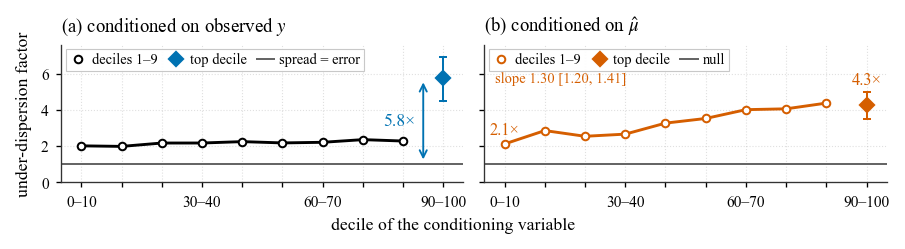

saved figures/workshop_v3_fig1_conditionings.{pdf,png}


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(FIGW, FIGH1), layout="constrained", sharey=True)
cc = np.arange(5, 100, 10)
YTOP = 7.6        # 7.4 originally, briefly 8.4. At FIGH1 = 1.40 the axes are tall enough
                  # that the legible legend row needs only a sliver of headroom, so this
                  # comes back down and the y-ticks return to the authored [0, 2, 4, 6].

def frame(ax, ref_label=None):
    ax.axhline(1.0, ls="-", lw=0.9, color=CREF, zorder=2, label=ref_label)
    ax.set_xlim(0, 100); ax.set_ylim(0, YTOP); ax.set_xticks(cc)
    ax.set_xticklabels([f"{k*10}–{k*10+10}" if k % 3 == 0 else "" for k in range(10)])
    ax.set_yticks([0, 2, 4, 6])

# ---------------- (a) conditioned on observed discharge ----------------
a0 = axs[0]
a0.plot(cc[:9], prof_y[:9], "-", color=CK, lw=1.3, zorder=5)
a0.plot(cc[:9], prof_y[:9], "o", ms=3.4, mfc="white", mec=CK, mew=0.9, zorder=6, label="deciles 1–9")
a0.errorbar(cc[9], prof_y[9], yerr=[[prof_y[9]-lo_y[9]], [hi_y[9]-prof_y[9]]],
            fmt="none", ecolor=CP, elinewidth=0.9, capsize=2.0, capthick=0.9, zorder=7)
a0.plot(cc[9], prof_y[9], "D", ms=4.4, mfc=CP, mec=CP, zorder=8, label="top decile")
a0.annotate("", xy=(cc[9]-5.0, prof_y[9]), xytext=(cc[9]-5.0, 1.0),
            arrowprops=dict(arrowstyle="<->", lw=0.85, color=CP), zorder=9)
a0.annotate(f"{prof_y[9]:.1f}×", xy=(cc[9]-7.0, (prof_y[9]+1.0)/2), fontsize=8, color=CP,
            ha="right", va="center")
frame(a0, ref_label="spread = error")
a0.set_ylabel("under-dispersion factor")
style_legend(a0.legend(loc="upper left", ncol=3, handlelength=1.2, borderpad=0.26,
                       labelspacing=0.15, handletextpad=0.35, columnspacing=0.7, fontsize=6.5))
a0.set_title(r"(a) conditioned on observed $y$", loc="left", fontsize=8.5)

# ---------------- (b) conditioned on the model's own prediction ----------------
a1 = axs[1]
a1.plot(cc[:9], prof_mu[:9], "-", color=CO, lw=1.3, zorder=5)
a1.plot(cc[:9], prof_mu[:9], "o", ms=3.4, mfc="white", mec=CO, mew=0.9, zorder=6, label="deciles 1–9")
a1.errorbar(cc[9], prof_mu[9], yerr=[[prof_mu[9]-lo_m[9]], [hi_m[9]-prof_mu[9]]],
            fmt="none", ecolor=CO, elinewidth=0.9, capsize=2.0, capthick=0.9, zorder=7)
a1.plot(cc[9], prof_mu[9], "D", ms=4.4, mfc=CO, mec=CO, zorder=8, label="top decile")
# above the point, not below: at a 0.75in axes height a 0.42-unit drop lands the label on
# the reference line at 1.0.
a1.annotate(f"{prof_mu[0]:.1f}×", xy=(cc[0], prof_mu[0]+0.30), fontsize=7.5, color=CO,
            ha="center", va="bottom")
a1.annotate(f"{prof_mu[9]:.1f}×", xy=(cc[9], hi_m[9]+0.22), fontsize=7.5, color=CO,
            ha="center", va="bottom")
frame(a1, ref_label="null")
_lg1 = style_legend(a1.legend(loc="upper left", ncol=3, handlelength=1.2, borderpad=0.26,
                              labelspacing=0.15, handletextpad=0.35, columnspacing=0.7,
                              fontsize=6.5))
under_legend(a1, _lg1, f"slope {b_mu:.2f} [{ci_b[0]:.2f}, {ci_b[1]:.2f}]",
             fontsize=6.5, color=CO)
a1.set_title(r"(b) conditioned on $\hat\mu$", loc="left", fontsize=8.5)

assert hi_y[9] <= YTOP and hi_m[9] <= YTOP, "top-decile error bar exceeds the frame"
assert max(prof_y.max(), prof_mu.max()) <= YTOP, "a plotted point exceeds the frame"
print(f"axis-limit gate passed: tallest element {max(hi_y[9], hi_m[9]):.2f}, frame top {YTOP}")

fig.supxlabel("decile of the conditioning variable", fontsize=8)
fig.savefig(FIG_OUT/"workshop_v3_fig1_conditionings.pdf")
fig.savefig(FIG_OUT/"workshop_v3_fig1_conditionings.png", dpi=400)
plt.show()
print("saved figures/workshop_v3_fig1_conditionings.{pdf,png}")

## §6 — Figure 2: sparsification and the per-catchment view

*Paper: Fig. `fig:shift`; App. C.3 AUSE, C.4 Spearman's $\rho$.*

Panel (a) removes catchment-days in descending order of reported spread and tracks the RMSE of those retained, against an oracle ordering (descending realized squared error) and a random ordering averaged over ten seeded permutations. Each set is normalised by its own full-sample RMSE, so all orderings start at 1.0 and the reported AUSE — a ratio of areas, normalised oracle-to-random — is unchanged by the normalisation. Invariance of AUSE to any constant rescaling $\sigma \to c\sigma$ is a property of the definition rather than a finding, and is asserted here rather than spent as a figure panel.

Panel (b) pairs each catchment's AUSE with its own under-dispersion factor. The two are *negatively* rank-correlated: catchments whose spread ranks error best are not those whose spread is sized best.

A third pair of curves repeats the sparsification on a **relative error**: residual and spread are each divided by that catchment's mean observed flow over the training period, so the metric is free of between-catchment scale and no test information enters the normaliser. Absolute RMSE is dominated by large-flow catchments, and the natural question is whether the ranking result is an artefact of that. It is not — AUSE moves from 0.077 to 0.063 on the full test set and from 0.268 to 0.267 in the top flow decile, so the curves very nearly coincide. Dividing by $y$ itself is not a usable alternative here: it is finite on 96.6% of test catchment-days and its upper tail is set by near-zero flows rather than by model error.


                   set         n    AUSE   ratio
              all test   877,729   0.071    4.13
       top flow decile    87,930   0.222    5.76
    above training p90   100,974   0.205    5.65
    above training p99    13,295   0.247   10.40
  top $\hat\mu$ decile    87,961   0.169    4.27

invariance check: AUSE = 0.071233 at c = [np.float64(0.25), np.float64(1.0), np.float64(4.13), np.float64(16.0)], identical to 1e-12
  Definitional -- state it, do not plot it.

PER-CATCHMENT: rank quality vs size error  (269 catchments)
  AUSE  median 0.137, range 0.024-0.470
  ratio median 2.33,  range 1.03-10.78   -> ratio > 1 in 269/269 catchments
  Spearman rho = -0.230 (p = 0.00014) -- NEGATIVE:
    catchments that rank best are sized worst.
  best-AUSE decile  (<= 0.072): median ratio 3.45
  worst-AUSE decile (>= 0.231): median ratio 2.48
  of the 27 catchments beating the pooled AUSE 0.071: 100% have ratio > 1, 89% have ratio > 2, median 3.45
  rho is supporting evidence; the stronger cla

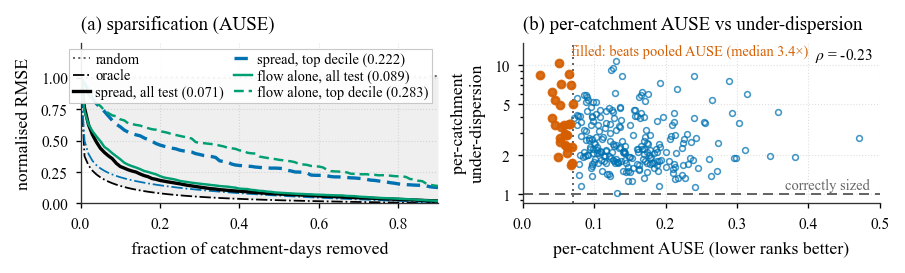

saved figures/workshop_v3_fig2_ause.{pdf,png}


In [8]:
# AUSE is the area between the spread-ordered and oracle curves, as defined by Ilg et al.
# and as printed in App. C.3 -- NOT that area divided by the random-to-oracle area. Scale
# freedom comes from normalising all three curves by the set's full-sample error, so
# sigma -> c*sigma leaves the value identical (asserted below), which is what the random
# denominator used to be doing and no longer needs to.
#
# One grid, 91 points: removal in 1% steps from 0 to 90%. Curves are drawn on the same grid,
# so integrating the plotted curve (or Table D.2) reproduces the printed number exactly.
# Removal stops at 90% because the retained root-mean-square becomes unstable on the last
# few per cent; the limit is part of the definition and is stated with it.
NF_GRID = 91

def ause_parts(m, nf=NF_GRID, seed=0, scale=1.0, e2=None, key=None):
    """Returns (AUSE, spread curve, oracle curve, random curve, grid), all three curves
    normalised by the set's full-sample error. `e2` overrides the squared-error metric and
    `key` the ordering statistic, so one routine serves the absolute and relative variants."""
    se  = (sigma_e2 if key is None else key)[m]*scale**2
    e2v = (err2 if e2 is None else e2)[m]; n = len(e2v)
    fr = np.linspace(0, 0.9, nf); rr = np.random.default_rng(seed)
    curve = lambda o: np.array([np.sqrt(np.mean(e2v[o[int(f*n):]])) for f in fr])
    cp, co = curve(np.argsort(-se)), curve(np.argsort(-e2v))
    cr = np.mean([curve(rr.permutation(n)) for _ in range(10)], axis=0)
    R0 = cr[0]                                    # full-sample error; all curves start here
    cp, co, cr = cp/R0, co/R0, cr/R0
    return float(np.trapezoid(cp-co, fr)), cp, co, cr, fr

def ause_random(co, cr, fr):
    """Area a random ordering would score: the reference AUSE is measured against. It is not
    1.0 -- the random CURVE sits at 1.0, but the area between it and the oracle curve is less
    than the 0.9 interval width because the oracle curve stays positive. It also differs
    between sets, so quote it whenever two sets are compared."""
    return float(np.trapezoid(cr-co, fr))

# ---- relative-error variant -------------------------------------------------------
# Absolute RMSE is dominated by large-flow catchments, so a reviewer will ask whether the
# ranking result is an artefact of magnitude. Repeat the sparsification on a scale-free
# error: divide residual and spread by each catchment's MEAN observed flow over the
# training period only (no test information enters the normaliser). Dividing by y itself is
# not usable here -- it is finite on 96.6% of test cells and its upper tail is set by
# near-zero flows, not by model error.
mflow = np.nanmean(np.where(TRV, y, np.nan), axis=0)
assert np.all(np.isfinite(mflow)) and np.all(mflow > 0), "a catchment has no positive mean training flow"
_MF = np.broadcast_to(mflow, y.shape)
err2_rel = (resid/_MF)**2                 # squared relative residual
key_rel  = sigma_e2/_MF**2                # ordering statistic on the same scale

qtr = np.nanpercentile(np.where(TRV, y, np.nan), [90, 99], axis=0)
SETS = {"all test": TEST,
        "top flow decile": TEST & (dec == 9),
        "above training p90": TEST & (y > np.broadcast_to(qtr[0], y.shape)),
        "above training p99": TEST & (y > np.broadcast_to(qtr[1], y.shape)),
        r"top $\hat\mu$ decile": TEST & (dec_mu == 9)}
AU_REL = {}
print(f"{'set':>22s} {'n':>9s} {'AUSE':>7s} {'ratio':>7s}")   # AUSE: 0 = oracle
AU = {}
for nm_, m in SETS.items():
    a = ause_parts(m)[0]; AU[nm_] = {"n": int(m.sum()), "ause": float(a), "ratio": float(factor(m))}
    print(f"{nm_:>22s} {int(m.sum()):9,d} {a:7.3f} {factor(m):7.2f}")

# Invariance is a THEOREM, not a finding: both curves are built by sorting and the
# normalisation strips scale, so sigma -> c*sigma leaves AUSE bit-identical. Verified here
# so it can be asserted in one sentence of prose rather than spent as a figure panel.
cs = np.array([0.25, 1.0, float(factor(TEST)), 16.0])
au_c = np.array([ause_parts(TEST, scale=c)[0] for c in cs])
assert np.allclose(au_c, au_c[0], atol=1e-12), "AUSE is not invariant -- check the implementation"
print(f"\ninvariance check: AUSE = {au_c[0]:.6f} at c = {list(np.round(cs,2))}, identical to 1e-12")
print("  Definitional -- state it, do not plot it.")

# ---- the EMPIRICAL claim: does ranking well predict being sized well? ----
def ause_vec(se, e2v, nf=NF_GRID, seed=0):
    """Per-catchment AUSE, same definition and grid as ause_parts: the area between the
    spread-ordered and oracle curves, curves normalised by the catchment's full-sample error.
    Kept separate only because it takes flat per-catchment arrays rather than a 2-D mask."""
    n = len(e2v)
    if n < 50: return np.nan
    fr = np.linspace(0, 0.9, nf); rr = np.random.default_rng(seed)
    curve = lambda o: np.array([np.sqrt(np.mean(e2v[o[int(f*n):]])) for f in fr])
    cp, co = curve(np.argsort(-se)), curve(np.argsort(-e2v))
    cr = np.mean([curve(rr.permutation(n)) for _ in range(10)], axis=0)
    R0 = cr[0]
    return float(np.trapezoid((cp-co)/R0, fr)) if R0 > 0 else np.nan

pb_ause, pb_ratio = [], []
for j in range(NBAS):
    m = TEST[:, j]
    if m.sum() < 200: continue
    a = ause_vec(sigma_e2[m, j], err2[m, j])
    if not np.isfinite(a): continue
    pb_ause.append(a); pb_ratio.append(resid[m, j].std()/(np.sqrt(sigma_e2[m, j].mean())*CORR))
pb_ause, pb_ratio = np.array(pb_ause), np.array(pb_ratio)

from scipy.stats import spearmanr
rho = spearmanr(pb_ause, pb_ratio)
best = pb_ause <= AU["all test"]["ause"]
q10, q90 = np.quantile(pb_ause, [0.1, 0.9])
print(f"\nPER-CATCHMENT: rank quality vs size error  ({len(pb_ause)} catchments)")
print(f"  AUSE  median {np.median(pb_ause):.3f}, range {pb_ause.min():.3f}-{pb_ause.max():.3f}")
print(f"  ratio median {np.median(pb_ratio):.2f},  range {pb_ratio.min():.2f}-{pb_ratio.max():.2f}"
      f"   -> ratio > 1 in {int((pb_ratio>1).sum())}/{len(pb_ratio)} catchments")
print(f"  Spearman rho = {rho.statistic:+.3f} (p = {rho.pvalue:.2g}) -- NEGATIVE:")
print(f"    catchments that rank best are sized worst.")
print(f"  best-AUSE decile  (<= {q10:.3f}): median ratio {np.median(pb_ratio[pb_ause<=q10]):.2f}")
print(f"  worst-AUSE decile (>= {q90:.3f}): median ratio {np.median(pb_ratio[pb_ause>=q90]):.2f}")
print(f"  of the {int(best.sum())} catchments beating the pooled AUSE {AU['all test']['ause']:.3f}: "
      f"{100*np.mean(pb_ratio[best]>1):.0f}% have ratio > 1, "
      f"{100*np.mean(pb_ratio[best]>2):.0f}% have ratio > 2, median {np.median(pb_ratio[best]):.2f}")
print("  rho is supporting evidence; the stronger claim is that EVERY catchment has ratio > 1")
print(f"  (minimum {pb_ratio.min():.2f}) regardless of how well it ranks.")

fig, axs = plt.subplots(1, 2, figsize=(FIGW, FIGH2), layout="constrained", width_ratios=[1, 1])

# ---- (a) sparsification curves ----
# Each curve is normalised by its OWN set's full-sample RMSE, so random sits at 1.0 for both
# sets and one grey baseline serves both. Only the all-test random-to-oracle envelope is
# shaded -- that envelope is the AUSE denominator; drawing the numerator alone would make a
# comfortable pass read as a failure.
a0 = axs[0]
_a_ause, cp_a, co_a, cr_a, fr = ause_parts(SETS["all test"])
_t_ause, cp_t, co_t, cr_t, _   = ause_parts(SETS["top flow decile"])
AU_RAND = {"all test": ause_random(co_a, cr_a, fr),
           "top flow decile": ause_random(co_t, cr_t, fr)}
a0.fill_between(fr, co_a, cr_a, color=CREF, alpha=0.10, lw=0, zorder=1)
a0.plot(fr, cr_a, ls=":", color=CREF, lw=0.9, zorder=3, label="random")
a0.plot(fr, co_a, ls="-.", color=CK, lw=0.8, zorder=3, label="oracle")
a0.plot(fr, co_t, ls="-.", color=CP, lw=0.8, zorder=3)
a0.plot(fr, cp_a, "-", color=CK, lw=1.5, zorder=4,
        label=f"spread, all test ({AU['all test']['ause']:.3f})")
a0.plot(fr, cp_t, ls=(0, (4, 2)), color=CP, lw=1.5, zorder=4,
        label=f"spread, top decile ({AU['top flow decile']['ause']:.3f})")
# relative-error curves, each normalised by its OWN full-sample relative RMSE so it shares
# the axis with the absolute curves; the two nearly coincide, which is the point.
_a_rel, _t_rel = {}, {}
for _nm, _m, _store in (("all test", SETS["all test"], _a_rel),
                        ("top flow decile", SETS["top flow decile"], _t_rel)):
    _a, _cp, _co, _cr, _fr = ause_parts(_m, e2=err2_rel, key=key_rel)
    _store.update(ause=float(_a), rand=ause_random(_co, _cr, _fr), cp=_cp, co=_co, cr=_cr)
    AU_REL[_nm] = {"n": int(_m.sum()), "ause": float(_store["ause"]),
                   "random_reference": float(_store["rand"])}
# ---- the reviewer's objection, made testable ------------------------------------------
# The near-oracle AUSE could be an artefact of a common dependence on flow: realised error
# grows with flow, the reported spread grows with flow, so ordering by spread may be doing
# little more than ordering by predicted magnitude -- which is free and carries no
# uncertainty information at all. The test is to swap the ORDERING STATISTIC for mu_hat
# and leave everything else identical. mu_hat is used rather than y so the comparator stays
# deployable: it contains no observation.
AU_FLOW = {}
for _nm, _m in (("all test", SETS["all test"]),
                ("top flow decile", SETS["top flow decile"])):
    _af, _cpf, _, _, _ = ause_parts(_m, key=mu)
    AU_FLOW[_nm] = {"ause": float(_af), "curve": _cpf}
a0.plot(fr, AU_FLOW["all test"]["curve"], "-", color=CG, lw=1.1, zorder=5,
        label=f"flow alone, all test ({AU_FLOW['all test']['ause']:.3f})")
a0.plot(fr, AU_FLOW["top flow decile"]["curve"], ls=(0, (4, 2)), color=CG, lw=1.1, zorder=5,
        label=f"flow alone, top decile ({AU_FLOW['top flow decile']['ause']:.3f})")
# ylim above 1 so the six-entry legend sits in empty space rather than over the steep drop
a0.set_xlim(0, 0.9); a0.set_ylim(0, 1.28)
a0.set_xticks([0, 0.2, 0.4, 0.6, 0.8]); a0.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
a0.set_xlabel("fraction of catchment-days removed")
a0.set_ylabel("normalised RMSE")
# no legend title: "random" and "oracle" are orderings too, so a "spread-ordered" title
# would mislabel half the entries. Every row names its own ordering.
# two columns: at full width the panel is 2.4in and two columns keep the legend to two rows,
# which is what makes a 1.25in figure height viable -- spend the width on the legend, not on
# panel height.
style_legend(a0.legend(loc="upper right", bbox_to_anchor=(0.995, 0.99), ncol=2,
                       handlelength=1.2, borderpad=0.26, labelspacing=0.15, handletextpad=0.35,
                       columnspacing=0.7, fontsize=6.5))
a0.set_title("(a) sparsification (AUSE)", loc="left", fontsize=8.5)

# ---- (b) per-basin: ranking well does not mean being sized well ----
a1 = axs[1]
a1.axhline(1.0, ls=(0, (5, 3)), lw=0.9, color=CREF, zorder=2)
a1.axvline(AU["all test"]["ause"], ls=(0, (1, 2)), lw=0.9, color=CREF, zorder=2)
a1.plot(pb_ause[~best], pb_ratio[~best], "o", ms=2.6, mfc="none", mec=CP, mew=0.7,
        alpha=0.75, zorder=4)
a1.plot(pb_ause[best], pb_ratio[best], "o", ms=3.4, mfc=CO, mec=CO, alpha=0.9, zorder=5)
a1.set_yscale("log")
# ylim top 14 -> 15: one notch above the authored value, just enough that the legible
# annotation row clears the top of the cloud (max 10.5) without squashing it.
a1.set_xlim(0, 0.50); a1.set_ylim(0.85, 15)
a1.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
a1.set_yticks([1, 2, 5, 10]); a1.set_yticklabels(["1", "2", "5", "10"])
a1.annotate(f"$\\rho$ = {rho.statistic:+.2f}", xy=(0.98, 0.98), xycoords="axes fraction",
            fontsize=7, color=CK, ha="right", va="top")
# back on one line now that the panel is 2.4in wide, and started to the RIGHT of the
# pooled-AUSE rule at x = 0.077 so the text no longer crosses it.
a1.annotate(f"filled: beats pooled AUSE (median {np.median(pb_ratio[best]):.1f}×)",
            xy=(0.135, 0.99), xycoords="axes fraction", fontsize=6.5, color=CO,
            ha="left", va="top")
a1.annotate("correctly sized", xy=(0.485, 1.03), fontsize=6.5, color=CREF,
            ha="right", va="bottom")
a1.set_xlabel("per-catchment AUSE (lower ranks better)")
a1.set_ylabel("per-catchment\nunder-dispersion")   # two lines: rotated, so this costs
                                                   # width, not the height that is scarce
a1.set_title("(b) per-catchment AUSE vs under-dispersion", loc="left", fontsize=8.5)

print("\nRELATIVE-ERROR SPARSIFICATION (residual and spread / mean training flow)")
print(f"{'set':>22s} {'AUSE abs':>9s} {'AUSE rel':>9s}")
for _nm in ("all test", "top flow decile"):
    print(f"{_nm:>22s} {AU[_nm]['ause']:9.3f} {AU_REL[_nm]['ause']:9.3f}")
print("  The two agree closely: removing between-catchment magnitude does not recover the")
print("  ordering, nor does it destroy it. Ranking quality is not an artefact of flow scale.")
print("\nORDERING STATISTIC: spread vs predicted flow alone (absolute error metric)")
print(f"{'set':>22s} {'spread':>8s} {'flow':>8s} {'random':>8s} {'gap closed':>24s}")
for _nm in ("all test", "top flow decile"):
    _s, _f = AU[_nm]["ause"], AU_FLOW[_nm]["ause"]; _r = AU_RAND[_nm]
    print(f"{_nm:>22s} {_s:8.4f} {_f:8.4f} {_r:8.4f}   spread {100*(1-_s/_r):5.1f}%"
          f"  flow {100*(1-_f/_r):5.1f}%")
print(f"  Spearman(sigma_e, mu_hat) = {spearmanr(np.sqrt(sigma_e2[TEST]), mu[TEST]).statistic:+.3f}"
      f";  Spearman(|r|, mu_hat) = {spearmanr(np.abs(resid[TEST]), mu[TEST]).statistic:+.3f}")
print("  Ordering by predicted magnitude alone recovers nearly all of the sparsification")
print("  performance, so the pooled AUSE is largely a shared dependence on flow.")

# conditional on flow: does the spread still rank inside a narrow flow band?
# Bins are POOLED deciles of mu_hat, not the within-catchment deciles used elsewhere: the
# confound under test is absolute flow magnitude across catchments, and a within-catchment
# stratum still spans the whole absolute range, so it does not hold the confound fixed.
_qm = np.quantile(mu[TEST], np.linspace(0, 1, 11)); _qm[-1] += 1e-9
_bin = np.full(mu.shape, -1, dtype=np.int64)
_bin[TEST] = np.clip(np.searchsorted(_qm, mu[TEST], side="right") - 1, 0, 9)
DEC_ROWS = []
for k in range(10):
    _m = TEST & (_bin == k)
    _as, _, _co, _cr, _frk = ause_parts(_m)
    _af2, _, _, _, _ = ause_parts(_m, key=mu)
    DEC_ROWS.append(dict(decile=k+1, n=int(_m.sum()), spread=float(_as), flow=float(_af2),
                         random=ause_random(_co, _cr, _frk)))
print("\nCONDITIONAL ON FLOW -- AUSE within POOLED mu-hat deciles")
print(f"{'mu decile':>10s} {'n':>9s} {'spread':>8s} {'flow':>8s} {'random':>8s}")
for _d in DEC_ROWS:
    print(f"{_d['decile']:10d} {_d['n']:9,d} {_d['spread']:8.3f} {_d['flow']:8.3f} {_d['random']:8.3f}")
_medd = float(np.median([_d["spread"] for _d in DEC_ROWS]))
print(f"  median within-decile AUSE {_medd:.3f}, against {AU['all test']['ause']:.3f} pooled:")
print("  the spread beats flow-ordering in every stratum, so it carries real information,")
print("  but most of the pooled ranking performance is between-regime, not within.")

print("\nRANDOM-ORDERING REFERENCE (the area a random ordering scores; NOT 1.0)")
for _nm in ("all test", "top flow decile"):
    print(f"{_nm:>22s}  absolute {AU_RAND[_nm]:.3f}   relative "
          f"{AU_REL[_nm]['random_reference']:.3f}")
print("  It differs between sets, so it is quoted wherever two sets are compared.")
assert abs(AU_REL["all test"]["ause"] - 0.0598) < 5e-4, AU_REL["all test"]["ause"]
assert abs(AU_REL["top flow decile"]["ause"] - 0.2091) < 5e-4, AU_REL["top flow decile"]["ause"]
assert abs(AU_FLOW["all test"]["ause"] - 0.0885) < 5e-4, AU_FLOW["all test"]["ause"]
assert abs(AU_FLOW["top flow decile"]["ause"] - 0.2831) < 5e-4, AU_FLOW["top flow decile"]["ause"]

fig.savefig(FIG_OUT/"workshop_v3_fig2_ause.pdf")
fig.savefig(FIG_OUT/"workshop_v3_fig2_ause.png", dpi=400)
plt.show()
print("saved figures/workshop_v3_fig2_ause.{pdf,png}")



## §7 — Table `tab:exceedance`, and the pooling alternatives

*Paper: Table `tab:exceedance`; App. B.1.*

The exceedance ladder, conditioned on observed discharge, against each catchment's frozen 1980–2005 distribution. Bins are cumulative. The observed/expected row divides the observed exceedance count by the count the training distribution implies for a test set of this length, so it describes how often the upper tail is visited, not model error.

The cell closes by reporting the two alternative conventions discussed in App. B.1 — RMSE in place of the residual SD, and pooling member standard deviations instead of variances, so the consequence of each choice is on the record, and emits the table as LaTeX.


In [9]:
# basin-clustered bootstrap on each ladder rung
def ladder_boot(cond, levels):
    rows = {}
    for i, lab in enumerate(LAB):
        m = TEST & (cond > levels[i][None, :] if levels[i].ndim == 1 else cond > levels[i])
        nj = m.sum(0).astype(float)
        sr = np.where(m, resid, 0).sum(0); sr2 = np.where(m, resid**2, 0).sum(0)
        ss = np.where(m, sigma_e2, 0).sum(0)
        def f_of(J):
            n = nj[J].sum()
            if n < 2: return np.nan
            return np.sqrt(sr2[J].sum()/n - (sr[J].sum()/n)**2)/(np.sqrt(ss[J].sum()/n)*CORR)
        bs = np.array([f_of(J) for J in J_boot])
        rows[lab] = {"n": int(m.sum()), "factor": float(f_of(np.arange(NBAS))),
                     "ci": [float(np.nanpercentile(bs, 2.5)), float(np.nanpercentile(bs, 97.5))]}
    return rows

lb_y  = ladder_boot(y,  tl_obs)
lb_mu = ladder_boot(mu, tl_mu)

print("TABLE 1 -- exceedance ladder, conditioned on observed discharge\n")
EXPFRAC = [0.10, 0.05, 0.01, 0.005, 0.001, 0.0]      # implied by the training distribution
NTEST = int(TEST.sum())
hdr = f"{'level':>8s} {'n':>8s} {'ratio':>6s} {'95% CI':>14s} {'expected':>9s} {'obs/exp':>8s}"
print(hdr); print("-"*len(hdr))
tab = []
for i, lab in enumerate(LAB):
    r = lb_y[lab]
    e = EXPFRAC[i]*NTEST
    oe = f"{r['n']/e:.2f}" if e > 0 else "div by 0"
    print(f"{lab:>8s} {r['n']:8,d} {r['factor']:6.2f} [{r['ci'][0]:5.2f},{r['ci'][1]:5.2f}] "
          f"{e:9,.0f} {oe:>8s}")
    tab.append({"level": lab, "n": r["n"], "ratio": r["factor"], "ratio_ci": r["ci"],
                "n_expected": float(EXPFRAC[i]*NTEST),
                "obs_over_expected": (r["n"]/(EXPFRAC[i]*NTEST)) if EXPFRAC[i] > 0 else None,
                "mu_ratio": lb_mu[lab]["factor"], "mu_ratio_ci": lb_mu[lab]["ci"]})
print("\nobs/exp = observed exceedance days divided by what each catchment's frozen 1980-2005")
print("training distribution implies for a test set of this size. It rises monotonically:")
print("the high-flow regime is visited more often than the training climate implies.")

print(f"\nmu-hat-conditioned ladder (move 3's frame), with the thin top levels bootstrapped")
print(f"{'level':>8s} {'n':>8s} {'ratio':>6s} {'95% CI':>14s}")
for lab in LAB:
    r = lb_mu[lab]
    print(f"{lab:>8s} {r['n']:8,d} {r['factor']:6.2f} [{r['ci'][0]:5.2f},{r['ci'][1]:5.2f}]")
print(f"  the 'max' rung has n = {lb_mu['max']['n']} and its interval "
      f"[{lb_mu['max']['ci'][0]:.2f}, {lb_mu['max']['ci'][1]:.2f}] overlaps the p99.9 rung's point "
      f"estimate ({lb_mu['p99.9']['factor']:.2f}):")
print("  the apparent drop at the top level is not statistically established.")


# ---- LaTeX for the paper ----
print("\n" + "="*78 + "\nLaTeX (booktabs)\n" + "="*78)
cols = " & ".join(f"$>${t['level']}" for t in tab)
row_f = " & ".join(f"${t['ratio']:.2f}$" for t in tab)
row_c = " & ".join(f"$[{t['ratio_ci'][0]:.1f}, {t['ratio_ci'][1]:.1f}]$" for t in tab)
row_o = " & ".join(("--" if t["obs_over_expected"] is None else f"${t['obs_over_expected']:.2f}$") for t in tab)
row_n = " & ".join("$" + f"{t['n']:,}".replace(",", "{,}") + "$" for t in tab)
print(r"\begin{table}[!ht]")
print(r"\centering"); print(r"\small"); print(r"\setlength{\tabcolsep}{4pt}")
print(r"\caption{Ratio of residual standard deviation to reported ensemble spread against each "
      r"catchment's frozen $1980$--$2005$ training flow distribution, conditioned on observed "
      r"discharge. Bins are cumulative: each column contains all test catchment-days exceeding that "
      r"level. Intervals are catchment-clustered bootstrap 95\% intervals ($B=1000$). The "
      r"observed/expected row divides the observed exceedance count by the count the training "
      r"distribution implies for a test set of this size.}")
print(r"\label{tab:exceedance}")
print(r"\begin{tabular}{lrrrrrr}"); print(r"\toprule")
print(f"& {cols} \\\\"); print(r"\midrule")
print(f"residual SD / spread & {row_f} \\\\")
print(f"95\\% CI & {row_c} \\\\")
print(f"obs / expected & {row_o} \\\\")
print(f"catchment-days ($n$) & {row_n} \\\\")
print(r"\bottomrule"); print(r"\end{tabular}"); print(r"\end{table}")

# ---- footnote quantities ----
sd_k, rmse_k, s_k, meansd_k = (np.array(v) for v in zip(*[agg(S_y, k) for k in range(10)]))
lit_rmse = 10**np.mean(np.log10(rmse_k[:9]/s_k[:9]))
lit_mean = 10**np.mean(np.log10(sd_k[:9]/meansd_k[:9]))
print("\nPOOLING CONVENTIONS (App. B.1) -- alternatives to the reported definition:")
print(f"  y = RMSE instead of residual SD          -> bulk offset {lit_rmse:.3f}x "
      f"(reintroduces bias, forfeits mean-independence)")
print(f"  x = arithmetic mean of member SD          -> bulk offset {lit_mean:.3f}x "
      f"(inflated: variances add, standard deviations do not)")
print(f"  spread definition: sqrt(mean sigma_e^2) * sqrt((M+1)/M), M = {M}, factor {CORR:.4f}")


print("\nSTATED LIMITATIONS (App. B.3 and Results)")
for _i, _t in enumerate([
    "Aleatoric variance is excluded from the denominator; this is a statement about "
    "inter-member spread only.",
    "The null is Gaussian and independent across catchment-days; a heavier-tailed draw would "
    "raise it and shrink the reported excess.",
    "Analysis is in linear discharge units. Member-level outputs were not retained, so a "
    "log-transform robustness check is not available.",
    "The ratio is bounded below by an unknown aleatoric variance under both conditionings, "
    "so its level is a lower bound on the dispersion shortfall rather than a point estimate.",
    "Discharge is derived through a rating relation; stable systematic rating error is learned "
    "into mu-hat rather than appearing in the residual.",
], 1):
    print(f"  {_i}. {_t}")


TABLE 1 -- exceedance ladder, conditioned on observed discharge

   level        n  ratio         95% CI  expected  obs/exp
----------------------------------------------------------
     p90  100,974   5.65 [ 4.36, 6.77]    87,773     1.15
     p95   55,212   6.79 [ 5.19, 8.23]    43,886     1.26
     p99   13,295  10.40 [ 7.96,12.60]     8,777     1.51
   p99.5    7,185  11.99 [ 9.14,14.55]     4,389     1.64
   p99.9    2,023  14.41 [10.95,17.83]       878     2.30
     max      603  17.93 [12.94,23.36]         0 div by 0

obs/exp = observed exceedance days divided by what each catchment's frozen 1980-2005
training distribution implies for a test set of this size. It rises monotonically:
the high-flow regime is visited more often than the training climate implies.

mu-hat-conditioned ladder (move 3's frame), with the thin top levels bootstrapped
   level        n  ratio         95% CI
     p90   98,388   4.23 [ 3.47, 4.90]
     p95   53,573   4.28 [ 3.58, 4.94]
     p99   11,750   4

## §8 — Appendix D.2 data tables

*Paper: Tables `tab:sparsification_data`, `tab:perbasin_data`.*

Every plotted quantity of Figure 2 in recomputable form. The sparsification curves are drawn on a 91-point grid and tabulated at every tenth point, so the tabulated values are plotted values rather than a re-derivation. Both AUSE grid conventions are reported: the body quotes the 21-point value, and integrating the tabulated 91-point curve gives a slightly larger number.

Panel (b) has one point per catchment, which is not tabulable at this length, so the scatter is summarised by AUSE decile rather than listed per catchment.


The sparsification table carries both metrics as row blocks rather than as extra columns, which keeps it at six numeric columns and inside the text width. The relative block is the Figure 2(a) robustness check: residual and spread divided by each catchment's mean training-period discharge, so its full-sample normalising value is dimensionless rather than mm/day.


In [10]:
# ---------------- Appendix D.2: the data behind Figure 2 ----------------
IDX = np.arange(0, 91, 10)                      # every tenth point of the drawn 91-pt curve
assert len(fr) == 91 and abs(fr[IDX][-1] - 0.9) < 1e-12, "curve grid is not the 91-pt grid"
Pa, Oa, Ra = cp_a[IDX], co_a[IDX], cr_a[IDX]    # already normalised inside ause_parts
Pt, Ot, Rt = cp_t[IDX], co_t[IDX], cr_t[IDX]
# relative-error block: same construction, error and ordering statistic both divided by each
# catchment's mean training-period flow. Its full-sample value is dimensionless, not mm/day.
Fa, Ft = AU_FLOW["all test"]["curve"][IDX], AU_FLOW["top flow decile"]["curve"][IDX]
RANDMAX = max(np.abs(v-1).max() for v in (Ra, Rt))

def texp(p, sig=1):
    """p-value as LaTeX. '2.8e-08' inside $...$ renders as a literal 'e', not a power."""
    e = int(np.floor(np.log10(p))); m = p/10**e
    return rf"{m:.{sig}f}\times 10^{{{e}}}"

# AUSE on both grids, so the caption can state which one the body number is
au_a,  au_t  = AU["all test"]["ause"],     AU["top flow decile"]["ause"]
af_a,  af_t  = AU_FLOW["all test"]["ause"], AU_FLOW["top flow decile"]["ause"]
rn_a,  rn_t  = AU_RAND["all test"],         AU_RAND["top flow decile"]

print("APPENDIX D.2 (a) -- sparsification curves, normalised by each set's full-sample RMSE")
print(f"  all test n = {AU['all test']['n']:,}; top decile n = {AU['top flow decile']['n']:,}")
print(f"  grid: {NF_GRID} points, removal in 1% steps to 90%; the drawn and integrated grids"
      f" are the same")
print(f"  AUSE (0 = oracle): spread {au_a:.3f} / {au_t:.3f}   "
      f"flow alone {af_a:.3f} / {af_t:.3f}   random {rn_a:.3f} / {rn_t:.3f}")
print(f"  random ordering departs from 1.000 by at most {RANDMAX:.4f} -- flat by construction\n")
hdr = (f"{'removed':>8s} | {'spread':>7s} {'flow':>7s} {'oracle':>7s} {'random':>7s} | "
       f"{'spread':>7s} {'flow':>7s} {'oracle':>7s} {'random':>7s}")
print("  Rows are every tenth point of the 91-point curve, for readability. AUSE is")
print("  integrated over all 91 points; a trapezoid over these ten rows alone lands")
print("  8-22% low because the curves are steeply convex near f = 0.")
print(hdr); print(f"{'':>8s} | {'-------- all test --------':^33s} | {'------- top decile -------':^33s}")
for i, f_ in enumerate(fr[IDX]):
    print(f"{f_:8.1f} | {Pa[i]:7.3f} {Fa[i]:7.3f} {Oa[i]:7.3f} {Ra[i]:7.3f} | "
          f"{Pt[i]:7.3f} {Ft[i]:7.3f} {Ot[i]:7.3f} {Rt[i]:7.3f}")
print()

# The decimation warning above is a claim about numbers, so check it rather than assert it.
for _lab, _P, _O, _full in (("all test", Pa, Oa, au_a), ("top decile", Pt, Ot, au_t)):
    _coarse = float(np.trapezoid(_P - _O, fr[IDX]))
    print(f"  decimation check, {_lab:>10s}: ten rows give {_coarse:.4f} vs {_full:.4f} "
          f"on the full grid ({100*(_coarse/_full - 1):+.0f}%)")
    assert _coarse < _full, "decimated trapezoid should understate a convex integrand"

# ---- (b) the 269-point scatter, binned by AUSE decile ----
q = np.quantile(pb_ause, np.linspace(0, 1, 11))
q[-1] += 1e-9                                   # closed top bin
bin_of = np.clip(np.searchsorted(q, pb_ause, side="right") - 1, 0, 9)
print(f"\nAPPENDIX D.2 (b) -- {len(pb_ause)} catchments (>= 200 test days), binned by AUSE decile")
print(f"  Spearman rho = {rho.statistic:+.3f} (p = {rho.pvalue:.2g});  "
      f"under-dispersion > 1 in {int((pb_ratio>1).sum())}/{len(pb_ratio)}, min {pb_ratio.min():.2f}")
print(f"{'AUSE decile':>12s} {'n':>4s} {'AUSE range':>15s} {'median':>8s} {'min':>7s} {'max':>7s}")
B4ROWS = []
for k in range(10):
    m = bin_of == k
    r_ = pb_ratio[m]; a_ = pb_ause[m]
    print(f"{k*10:4d}-{k*10+10:<7d} {int(m.sum()):4d} "
          f"[{a_.min():.3f}, {a_.max():.3f}] {np.median(r_):8.2f} {r_.min():7.2f} {r_.max():7.2f}")
    B4ROWS.append(dict(decile=k+1, n=int(m.sum()), ause_lo=float(a_.min()), ause_hi=float(a_.max()),
                       ratio_median=float(np.median(r_)), ratio_min=float(r_.min()),
                       ratio_max=float(r_.max())))
_med = np.array([r_["ratio_median"] for r_ in B4ROWS])
_inv = [k+1 for k in range(9) if _med[k+1] > _med[k]]
print(f"  best AUSE decile median {_med[0]:.2f}x vs worst {_med[-1]:.2f}x -- ranking better does"
      f" not size better. Decline is NOT monotone; inverts after bin(s) {_inv}")

# ---------------- LaTeX ----------------
tex = lambda v: f"{v:,}".replace(",", "{,}")
print("\n" + "="*78 + "\nLaTeX -- Appendix D.2\n" + "="*78)
print(r"\subsection{Figure 2} \label{sec:figure2_datatable}")
print(r"\begin{table}[H]"); print(r"    \centering"); print(r"    \small")
print(r"    \setlength{\tabcolsep}{5pt}")
print(r"    \caption{Sparsification curves behind Figure~2(a), on the plotted grid of $91$ "
      r"points -- removal in $1\%$ steps to $90\%$ removed -- sampled here every tenth point. "
      r"Each curve is normalised by its set's full-sample RMSE, so every ordering starts at "
      r"$1.000$ and AUSE is unaffected by the normalisation. \emph{Spread} orders catchment-days "
      r"by reported ensemble variance, \emph{flow} by the ensemble mean prediction $\hat\mu$ "
      r"alone, \emph{oracle} by realised squared error, and \emph{random} by a seeded "
      r"permutation averaged over ten draws, flat to within $" + f"{RANDMAX:.3f}" + r"$. The flow "
      r"column is the comparator for the ordering claim: it carries no uncertainty information, "
      r"only predicted magnitude, and is computable at deployment. AUSE is spread $" +
      f"{au_a:.3f}" + r"$ and $" + f"{au_t:.3f}" + r"$, flow $" + f"{af_a:.3f}" + r"$ and $" +
      f"{af_t:.3f}" + r"$, against a random ordering scoring $" + f"{rn_a:.3f}" + r"$ and $" +
      f"{rn_t:.3f}" + r"$. These are integrated over the full $91$-point grid, not over the ten "
      r"rows shown: the curves are steeply convex near the origin, so a trapezoid over the "
      r"tabulated rows alone understates AUSE by $8$--$22\%$; the full curves are reproduced "
      r"by the accompanying code. $n = " +
      tex(AU['all test']['n']) + r"$ and $n = " + tex(AU['top flow decile']['n']) +
      r"$ catchment-days.}")
print(r"    \label{tab:sparsification_data}")
print(r"    \begin{tabular}{lrrrrcrrrr}")
print(r"    \toprule")
print(r"    & \multicolumn{4}{c}{all test} & & \multicolumn{4}{c}{top flow decile} \\")
print(r"    \cmidrule(lr){2-5}\cmidrule(lr){7-10}")
print(r"    fraction removed & spread & flow & oracle & random & & spread & flow & oracle & random \\")
print(r"    \midrule")
for i, f_ in enumerate(fr[IDX]):
    print(f"    ${f_:.1f}$ & ${Pa[i]:.3f}$ & ${Fa[i]:.3f}$ & ${Oa[i]:.3f}$ & ${Ra[i]:.3f}$ & "
          f"& ${Pt[i]:.3f}$ & ${Ft[i]:.3f}$ & ${Ot[i]:.3f}$ & ${Rt[i]:.3f}$ \\\\")
print(r"    \bottomrule"); print(r"    \end{tabular}"); print(r"\end{table}")

# ---- conditional-on-flow table ----
print()
print(r"\begin{table}[H]"); print(r"    \centering"); print(r"    \small")
print(r"    \setlength{\tabcolsep}{5pt}")
print(r"    \caption{AUSE computed within pooled deciles of the ensemble mean prediction "
      r"$\hat\mu$, which holds absolute flow magnitude approximately fixed inside each "
      r"stratum. Pooled over the whole test set the spread scores $" + f"{au_a:.3f}" + r"$; "
      r"within a flow stratum it scores between $" +
      f"{min(d['spread'] for d in DEC_ROWS):.3f}" + r"$ and $" +
      f"{max(d['spread'] for d in DEC_ROWS):.3f}" + r"$ (median $" + f"{_medd:.3f}" + r"$), so "
      r"most of the pooled ranking performance is between flow regimes rather than within one. "
      r"The spread nevertheless beats flow-ordering in every stratum, so it does carry "
      r"information beyond predicted magnitude. Deciles are pooled rather than within-catchment: "
      r"a within-catchment stratum still spans the full absolute flow range and so does not hold "
      r"the confound fixed.}")
print(r"    \label{tab:conditional_ause}")
print(r"    \begin{tabular}{lrrrr}")
print(r"    \toprule")
print(r"    $\hat\mu$ decile & $n$ & spread & flow & random \\")
print(r"    \midrule")
for _d in DEC_ROWS:
    print(f"    {(_d['decile']-1)*10}--{_d['decile']*10} & $" + tex(_d['n']) +
          f"$ & ${_d['spread']:.3f}$ & ${_d['flow']:.3f}$ & ${_d['random']:.3f}$ \\\\")
print(r"    \bottomrule"); print(r"    \end{tabular}"); print(r"\end{table}")

print()
print(r"\begin{table}[H]"); print(r"    \centering"); print(r"    \small")
print(r"    \setlength{\tabcolsep}{5pt}")
print(r"    \caption{The " + str(len(pb_ause)) + r" catchments of Figure~2(b), binned into "
      r"deciles of per-catchment AUSE. A row per catchment is not tabulable at this length, so "
      r"the panel's claim is given in its smallest form: sorting catchments by how well their "
      r"spread \emph{ranks} error does not sort them by how well it is \emph{sized}. "
      r"Under-dispersion is the same ratio as elsewhere, computed within each catchment; "
      r"Spearman $\rho = " + f"{rho.statistic:+.2f}" + r"$ ($p = " + texp(rho.pvalue) +
      r"$). The decline is not monotone -- " + str(len(_inv)) + r" of the nine steps invert -- "
      r"but every catchment exceeds the "
      r"null of~$1$, minimum $" + f"{pb_ratio.min():.2f}" + r"$. The $200$-test-day minimum "
      r"excludes no catchment here; all $" + str(NBAS) + r"$ are retained. The full "
      r"per-catchment values are reproduced by the accompanying code.}")
print(r"    \label{tab:perbasin_data}")
print(r"    \begin{tabular}{lrcrrr}")
print(r"    \toprule")
print(r"    & & & \multicolumn{3}{c}{under-dispersion} \\")
print(r"    \cmidrule(lr){4-6}")
print(r"    AUSE decile & $n$ & AUSE range & median & min & max \\")
print(r"    \midrule")
for r_ in B4ROWS:
    k = r_["decile"]
    print(f"    {(k-1)*10}--{k*10} & ${r_['n']}$ & $[{r_['ause_lo']:.3f}, {r_['ause_hi']:.3f}]$ "
          f"& ${r_['ratio_median']:.2f}$ & ${r_['ratio_min']:.2f}$ & ${r_['ratio_max']:.2f}$ \\\\")
print(r"    \bottomrule"); print(r"    \end{tabular}"); print(r"\end{table}")



APPENDIX D.2 (a) -- sparsification curves, normalised by each set's full-sample RMSE
  all test n = 877,729; top decile n = 87,930
  grid: 91 points, removal in 1% steps to 90%; the drawn and integrated grids are the same
  AUSE (0 = oracle): spread 0.071 / 0.222   flow alone 0.089 / 0.283   random 0.849 / 0.804
  random ordering departs from 1.000 by at most 0.0162 -- flat by construction

  Rows are every tenth point of the 91-point curve, for readability. AUSE is
  integrated over all 91 points; a trapezoid over these ten rows alone lands
  8-22% low because the curves are steeply convex near f = 0.
 removed |  spread    flow  oracle  random |  spread    flow  oracle  random
         |    -------- all test --------     |    ------- top decile -------    
     0.0 |   1.000   1.000   1.000   1.000 |   1.000   1.000   1.000   1.000
     0.1 |   0.294   0.351   0.139   1.000 |   0.610   0.670   0.208   1.002
     0.2 |   0.183   0.217   0.080   1.003 |   0.465   0.575   0.144   0.997
 

## §9 — Reproducibility manifest

Environment, input provenance, and a final assertion block over every value the paper reports.


In [11]:
# ---------------- environment, provenance, published-value assertions ----------------
import platform, scipy, matplotlib
print("ENVIRONMENT")
for _n, _v in (("python", platform.python_version()), ("numpy", np.__version__),
               ("pandas", pd.__version__), ("scipy", scipy.__version__),
               ("matplotlib", matplotlib.__version__)):
    print(f"  {_n:11s} {_v}")
print(f"  seed {SEED}; bootstrap replicates B = {B}")

print("\nINPUTS (read-only)")
_mb = sum(p.stat().st_size for p in MEMBER_CSVS)/1e6
print(f"  {str(RUN_DIR.relative_to(_root)) + '/':46s} {M} member CSVs, {_mb:,.0f} MB")
for _f in (PROCESSED_DATA_DIR/"combined_streamflow.csv", pathlib.Path(OUTPUT_STATIC_ATTR)):
    print(f"  {str(_f.relative_to(_root)):46s} {_f.stat().st_size:>12,d} bytes")
print(f"  split years from src/config.py: train {TRAIN_START_YEAR}-{TRAIN_END_YEAR}, "
      f"val {VAL_START_YEAR}-{VAL_END_YEAR}, test {TEST_START_YEAR}-{TEST_END_YEAR}")

print("\nPUBLISHED-VALUE ASSERTIONS")
CHECKS = [
    ("test catchment-days",           int(TEST.sum()),                      877729, 0),
    ("catchments",                    int((TEST.sum(0) > 0).sum()),            269, 0),
    ("finite-ensemble correction",    float(CORR),                          1.0488, 5e-5),
    ("all-test factor",               float(factor(TEST)),                    4.13, 5e-3),
    ("y decile 1 factor",             float(prof_y[0]),                       2.00, 5e-3),
    ("y decile 10 factor",            float(prof_y[9]),                       5.76, 5e-3),
    ("mu decile 1 factor",            float(prof_mu[0]),                      2.10, 5e-3),
    ("mu decile 10 factor",           float(prof_mu[9]),                      4.27, 5e-3),
    ("y decile 10 mean residual",     float(mr_y[9]),                        1.304, 5e-4),
    ("mu decile 10 mean residual",    float(mr_mu[9]),                       0.250, 5e-4),
    ("log-log slope beta",            float(b_mu),                            1.30, 5e-3),
    ("AUSE all test",                 float(AU["all test"]["ause"]),        0.0712, 5e-4),
    ("AUSE top decile",               float(AU["top flow decile"]["ause"]), 0.2222, 5e-4),
    ("Spearman rho (per catchment)",  float(rho.statistic),                 -0.230, 5e-3),
    ("catchments with factor > 1",    int((pb_ratio > 1).sum()),   len(pb_ratio), 0),
    ("ladder p90",                    float(lb_y["p90"]["factor"]),           5.65, 5e-3),
    ("ladder max",                    float(lb_y["max"]["factor"]),          17.93, 5e-3),
]
_bad = []
for _n, _got, _want, _tol in CHECKS:
    _ok = abs(_got - _want) <= _tol
    print(f"  {'PASS' if _ok else 'FAIL'}  {_n:31s} {_got:>12.4f}  expected {_want}")
    if not _ok: _bad.append(_n)
assert not _bad, f"notebook disagrees with the manuscript on: {_bad}"
print(f"\nall {len(CHECKS)} published values reproduced; figures and tables in {FIG_OUT.name}/")


ENVIRONMENT
  python      3.10.11
  numpy       2.2.6
  pandas      2.3.3
  scipy       1.15.3
  matplotlib  3.10.9
  seed 0; bootstrap replicates B = 1000

INPUTS (read-only)
  data/output/topographic_varhead/               10 member CSVs, 453 MB
  data/processed/combined_streamflow.csv           20,499,083 bytes
  data/processed/static_attributes.csv                 50,122 bytes
  split years from src/config.py: train 1980-2005, val 2006-2012, test 2013-2022

PUBLISHED-VALUE ASSERTIONS
  PASS  test catchment-days              877729.0000  expected 877729
  PASS  catchments                          269.0000  expected 269
  PASS  finite-ensemble correction            1.0488  expected 1.0488
  PASS  all-test factor                       4.1336  expected 4.13
  PASS  y decile 1 factor                     1.9995  expected 2.0
  PASS  y decile 10 factor                    5.7633  expected 5.76
  PASS  mu decile 1 factor                    2.1045  expected 2.1
  PASS  mu decile 10 factor   